In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

### 1. Build and show the confusion matrix obtained by cross validation, where the errors are on the test sets.

In [2]:
# 1. Caricamento del dataset
iris = load_iris()
X, y = iris.data, iris.target
class_names = iris.target_names

In [3]:
# 2. Inizializzazione del modello
# Fissiamo un random_state per garantire la riproducibilità dei risultati
clf = DecisionTreeClassifier(random_state=42)

In [4]:
# 3. Configurazione della Cross Validation
# Usiamo StratifiedKFold (default a 5 fold) per mantenere bilanciate le proporzioni delle classi nei fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [5]:
# 4. Generazione delle predizioni 'out-of-fold' (predizioni calcolate unicamente sui test set)
y_pred_cv = cross_val_predict(clf, X, y, cv=cv)

In [6]:
# 5. Calcolo della matrice di confusione
cm = confusion_matrix(y, y_pred_cv)

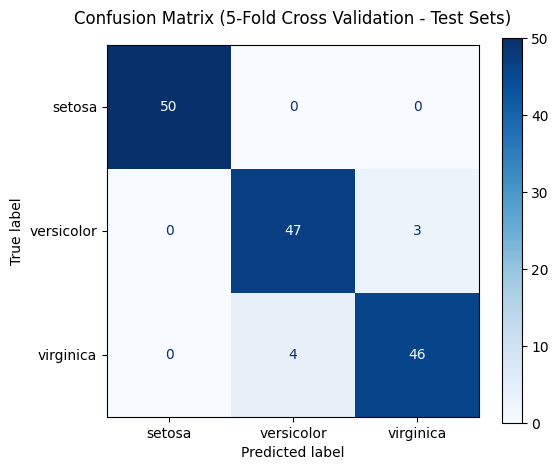

In [7]:
# 6. Visualizzazione grafica
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
plt.title("Confusion Matrix (5-Fold Cross Validation - Test Sets)", pad=15)
plt.show()

In [8]:
# 7. Report metriche dettagliate
print("Classification Report (Cross-Validation Test Sets):\n")
print(classification_report(y, y_pred_cv, target_names=class_names))

Classification Report (Cross-Validation Test Sets):

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.92      0.94      0.93        50
   virginica       0.94      0.92      0.93        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



### 2. build the ROC curve (or coverage curve in coverage space) and plot it for the tree: you have to build three curves, one for each class, considered in turn as the positive class.

In [12]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict

In [20]:
# 1. Binarizzazione dei target per l'approccio One-vs-Rest (OvR)
# Shape risultante: (n_samples, 3) con valori 0 o 1
y_bin = label_binarize(y, classes=[0, 1, 2])
n_classes = y_bin.shape[1]

In [21]:
# 2. Modello e Cross-Validation
clf = DecisionTreeClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [25]:
# 3. Predizione delle probabilità a posteriori sui test set (out-of-fold)
y_score = cross_val_predict(clf, X, y, cv=cv, method='predict_proba')

In [23]:
# 4. Calcolo ROC e AUC per ogni classe (One-vs-Rest)
# i=0 (setosa): tutte le setosa diventano 1, tutte le altre diventano 0
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

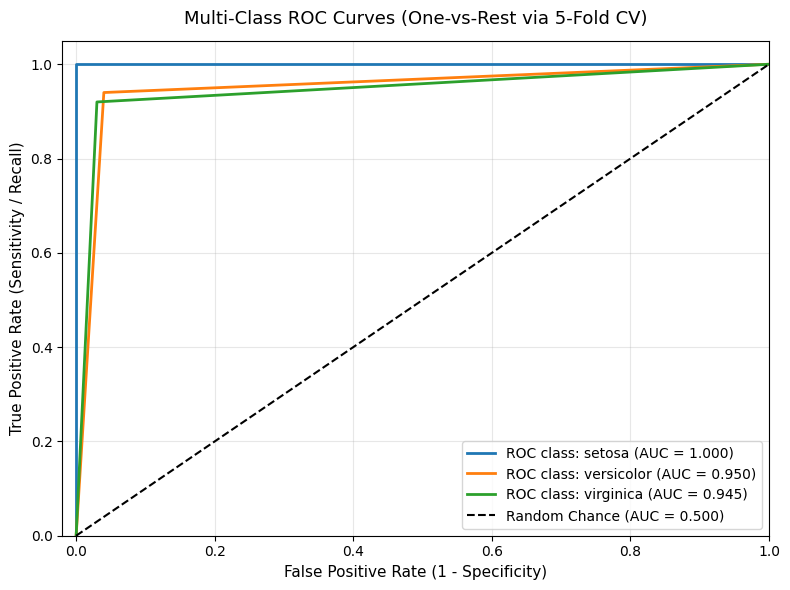

In [26]:
# 5. Visualizzazione grafica delle 3 Curve ROC
plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f"ROC class: {class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

# Baseline di un classificatore casuale
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.500)')

plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('Multi-Class ROC Curves (One-vs-Rest via 5-Fold CV)', fontsize=13, pad=12)
plt.legend(loc="lower right", frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# 6. Tabella riassuntiva dei valori AUC
print("Riassunto AUC per Classe:")
for i, name in enumerate(class_names):
    print(f" - {name:12s}: AUC = {roc_auc[i]:.4f}")

Riassunto AUC per Classe:
 - setosa      : AUC = 1.0000
 - versicolor  : AUC = 0.9500
 - virginica   : AUC = 0.9450


### 3. get an artificial inflation of the Virginica class in the training set by a given factor: 10 (weigh more the class virginica which is difficult to discriminate with versicolor). Learn the tree in this condition. In this case we have more examples in the dataset!

**Note:** Be careful in the random sampling when you divide the dataset into training- and test-set: no examples of the training-set should go in the test- set.


In [34]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [35]:
# 1. Caricamento dataset
iris = load_iris()
X, y = iris.data, iris.target
class_names = iris.target_names

In [36]:
# 2. Suddivisione Train / Test (PRIMA di qualsiasi campionamento per evitare Data Leakage)
# Usiamo uno split 70/30 stratificato
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Dimensioni del Train Set originale: {X_train.shape[0]} campioni")
print(f"Campioni per classe nel Train Set originale: {np.bincount(y_train)}")

Dimensioni del Train Set originale: 105 campioni
Campioni per classe nel Train Set originale: [35 35 35]


In [38]:
# Replica dei campioni di un fattore 10 (9 repliche aggiunte all'originale = 10x totale)
inflation_factor = 10
X_virginica_inflated = np.repeat(X_virginica, inflation_factor - 1, axis=0)
y_virginica_inflated = np.repeat(y_virginica, inflation_factor - 1, axis=0)

# Concatenazione con il dataset di training
X_train_inflated = np.vstack([X_train, X_virginica_inflated])
y_train_inflated = np.concatenate([y_train, y_virginica_inflated])

print(f"\nDimensioni del Train Set post-inflazione: {X_train_inflated.shape[0]} campioni")
print(f"Distribuzione classi nel Train Set gonfiato: {np.bincount(y_train_inflated)}")
print(f"Campioni nel Test Set (intatto): {len(y_test)} campioni")


Dimensioni del Train Set post-inflazione: 420 campioni
Distribuzione classi nel Train Set gonfiato: [ 35  35 350]
Campioni nel Test Set (intatto): 45 campioni


In [39]:
# 4. Addestramento del Decision Tree sul Train Set inflazionato
clf_inflated = DecisionTreeClassifier(random_state=42)
clf_inflated.fit(X_train_inflated, y_train_inflated)

DecisionTreeClassifier(random_state=42)

In [40]:
# 5. Predizione e valutazione sul Test Set NON alterato
y_pred_test = clf_inflated.predict(X_test)

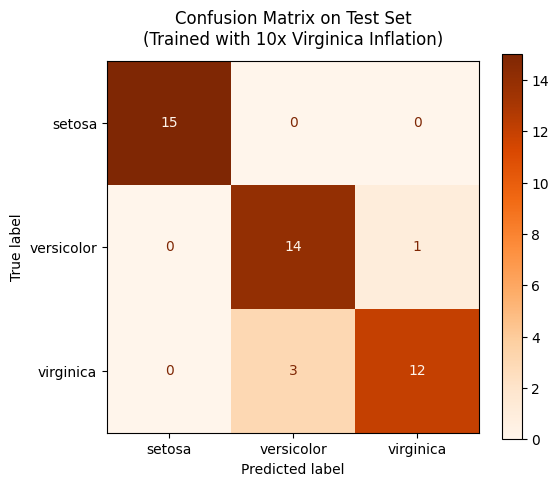

In [41]:
# 6. Visualizzazione della Matrice di Confusione
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Oranges, values_format='d', ax=ax)
plt.title(f"Confusion Matrix on Test Set\n(Trained with 10x Virginica Inflation)", pad=12)
plt.show()

In [44]:
# 7. Classification Report sul Test Set
print("Classification Report sul Test Set:\n")
print(classification_report(y_test, y_pred_test, target_names=class_names))

Classification Report sul Test Set:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



### 4. As an alternative to step 3, modify instead the weight of the Virginica class (set to 10 the weight for misclassification of Virginica) and learn the tree in this condition. You should obtain similar results as for step 3.

**Note:** Be careful to the values of the iperparameters you use if you want to obtain the same results as with the step 3 (such as min_samples_split, min_samples_leaf, max_leaf_nodes): they should be set in a value that is proportionated to the number of examples in the training-set.


In [45]:
# 1. Definizione dei pesi delle classi:
# Diamo peso 1 a Setosa (0) e Versicolor (1), e peso 10 a Virginica (2)
weights = {0: 1.0, 1: 1.0, 2: 10.0}

In [46]:
# 2. Inizializzazione del modello con pesatura delle classi (Cost-Sensitive Learning)
# Manteniamo lo stesso random_state per confrontabilità
clf_weighted = DecisionTreeClassifier(
    class_weight=weights,
    random_state=42
)

In [47]:
# 3. Addestramento sul Train Set ORIGINALE (non duplicato fisicamente!)
clf_weighted.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 1.0, 1: 1.0, 2: 10.0}, random_state=42)

In [49]:
# 4. Predizione sul Test Set intatto
y_pred_weighted = clf_weighted.predict(X_test)

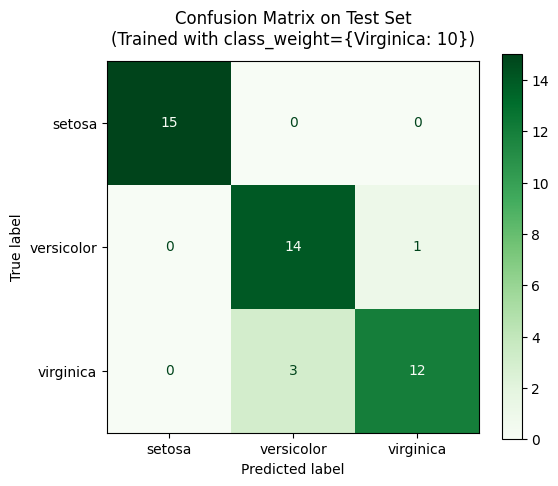

In [50]:
# 5. Visualizzazione della Matrice di Confusione
fig, ax = plt.subplots(figsize=(6, 5))
cm_weighted = confusion_matrix(y_test, y_pred_weighted)
disp_weighted = ConfusionMatrixDisplay(confusion_matrix=cm_weighted, display_labels=class_names)
disp_weighted.plot(cmap=plt.cm.Greens, values_format='d', ax=ax)
plt.title("Confusion Matrix on Test Set\n(Trained with class_weight={Virginica: 10})", pad=12)
plt.show()

In [51]:
# 6. Classification Report
print("Classification Report (Class-Weighted Model):\n")
print(classification_report(y_test, y_pred_weighted, target_names=class_names))

Classification Report (Class-Weighted Model):

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



In [52]:
# 7. Confronto diretto tra Metodo 3 (Inflazione) e Metodo 4 (Pesi)
print("-" * 50)
print("Verifica equivalenza predizioni tra Metodo 3 e Metodo 4:")
matching_predictions = (y_pred_test == y_pred_weighted).sum()
total_test = len(y_test)
print(f"Predizioni identiche: {matching_predictions}/{total_test} ({matching_predictions/total_test * 100:.1f}%)")

--------------------------------------------------
Verifica equivalenza predizioni tra Metodo 3 e Metodo 4:
Predizioni identiche: 45/45 (100.0%)


### 5. learn the tree but try to avoid overfitting (by improving the error on the test set). You can do tuning of the hyper-parameters using the function [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).



In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [65]:
# 1. Definizione della griglia di iperparametri per contrastare l'overfitting
# Nota sui range: Iris ha 4 feature e circa 105 campioni nel train set.
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 2, 3, 4, 5],                      # Limita la profondità massima
    'min_samples_split': [2, 5, 10],                      # Minimo campioni per dividere un nodo
    'min_samples_leaf': [1, 2, 4],                        # Minimo campioni per foglia (anti-foglie isolate)
    'max_features': [None, 'sqrt', 'log2'],               # Feature considerate per split
    'max_leaf_nodes': [None, 3, 5, 8],                    # Tetto sul numero massimo di foglie
    'min_impurity_decrease': [0.0, 0.01, 0.02],           # Soglia minima di guadagno informativo
    'ccp_alpha': [0.0, 0.005, 0.01, 0.02]                 # Cost-Complexity Pruning (post-potatura)
}

In [66]:
# 2. Inizializzazione del modello base e della cross-validation
base_tree = DecisionTreeClassifier(random_state=42)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [67]:
# 3. Configurazione di GridSearchCV
grid_search = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,        # Parallelizza su tutti i core CPU disponibili
    verbose=1
)

In [68]:
# 4. Esecuzione della ricerca sul Train Set
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 38880 candidates, totalling 194400 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'ccp_alpha': [0.0, 0.005, 0.01, 0.02],
                         'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [None, 2, 3, 4, 5],
                         'max_features': [None, 'sqrt', 'log2'],
                         'max_leaf_nodes': [None, 3, 5, 8],
                         'min_impurity_decrease': [0.0, 0.01, 0.02],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']},
             scoring='accuracy', verbose=1)

In [69]:
# 5. Estrazione e stampa della migliore configurazione
best_tree = grid_search.best_estimator_
print("\n" + "="*50)
print("MIGLIORI IPERPARAMETRI TROVATI:")
for param, value in grid_search.best_params_.items():
    print(f" - {param:22s}: {value}")
print(f"Miglior accuratezza media in CV (Train): {grid_search.best_score_:.4f}")
print("="*50)


MIGLIORI IPERPARAMETRI TROVATI:
 - ccp_alpha             : 0.0
 - criterion             : gini
 - max_depth             : None
 - max_features          : None
 - max_leaf_nodes        : None
 - min_impurity_decrease : 0.0
 - min_samples_leaf      : 1
 - min_samples_split     : 10
 - splitter              : random
Miglior accuratezza media in CV (Train): 0.9714


In [70]:
# 6. Valutazione sul Test Set (Out-of-sample)
y_pred_best = best_tree.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_best)
print(f"\nAccuratezza finale sul Test Set: {test_acc:.4f}\n")
print("Classification Report sul Test Set:\n")
print(classification_report(y_test, y_pred_best, target_names=class_names))


Accuratezza finale sul Test Set: 0.8667

Classification Report sul Test Set:

              precision    recall  f1-score   support

      setosa       1.00      0.93      0.97        15
  versicolor       0.80      0.80      0.80        15
   virginica       0.81      0.87      0.84        15

    accuracy                           0.87        45
   macro avg       0.87      0.87      0.87        45
weighted avg       0.87      0.87      0.87        45



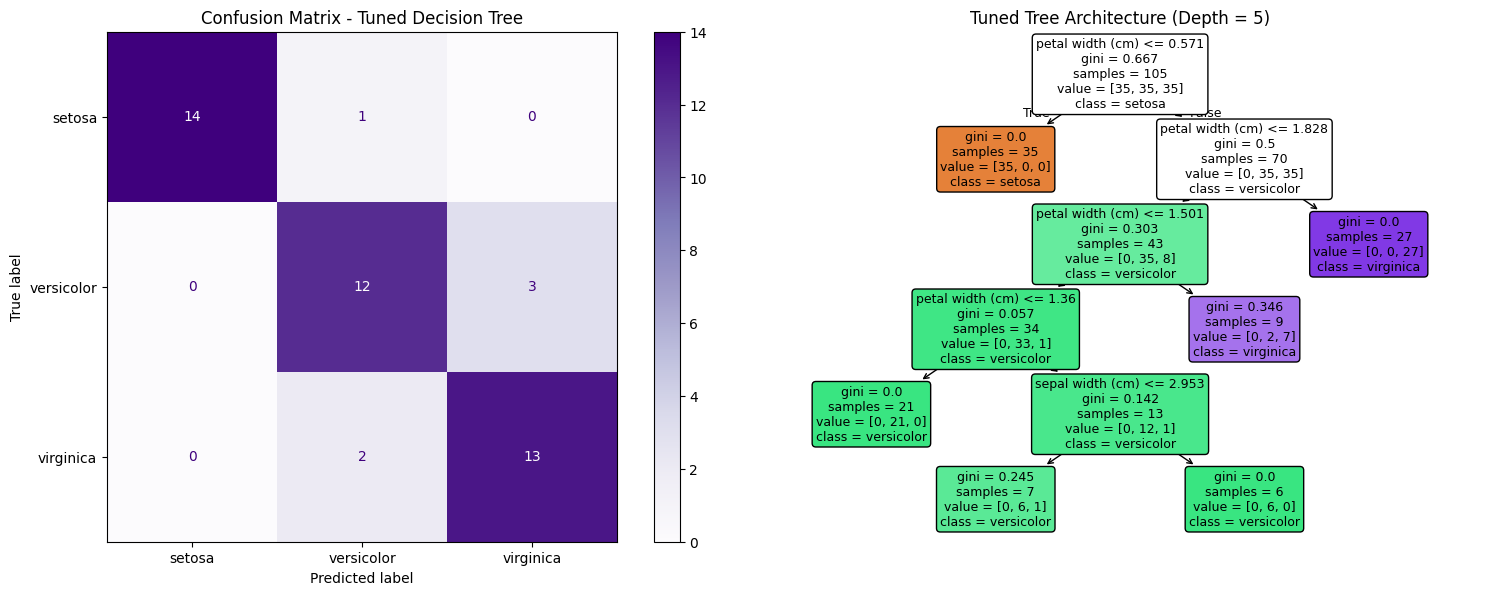

In [79]:
# 7. Matrice di Confusione del modello ottimizzato
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sinistra: Matrice di Confusione
cm_best = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=class_names)
disp.plot(cmap=plt.cm.Purples, values_format='d', ax=axes[0])
axes[0].set_title("Confusion Matrix - Tuned Decision Tree")

# Destra: Albero di Decisione
plot_tree(
    best_tree,
    feature_names=iris.feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=axes[1]
)
axes[1].set_title(f"Tuned Tree Architecture (Depth = {best_tree.get_depth()})")

plt.tight_layout()
plt.show()